In [1]:
import os
import re
import fitz
import string
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
DATA_DIR = '../school_knowledge_base/'

# Функции

In [3]:
def clean_text(text):
    """Функция для очистки текста"""
    # Убираем лишние переносы строк внутри абзацев
    text = re.sub(r'(?<=[^\.!?])\n+(?=[а-яёa-z])', ' ', text)
    # убираем множественные пробелы
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [4]:
def format_size(bytes_size):
    """
    Функция для конвертации байтов в читаемый формат
    Args:
        bytes_size: размер в байтах
    """
    for unit in ['B', 'KB', 'MB', 'GB']:
        if bytes_size < 1024:
            return f"{bytes_size:.2f} {unit}"
        bytes_size /= 1024

# Анализ
## Чтение файлов

In [10]:
data = []

for root, _, files in os.walk(DATA_DIR):
    for file in files:
        path = os.path.join(root, file)
        extension = file.split('.')[-1].lower()
        size = os.path.getsize(path)
        text = ''

        try:
            if extension == 'md':
                with open(path, 'r', encoding='utf-8') as f:
                    text = f.read()

            elif extension == 'pdf':
                doc = fitz.open(path)
                for page in doc:
                    text += page.get_text()
                text = clean_text(text)

            if text:
                data.append({
                    'file': file,
                    'format': extension,
                    'text': text,
                    'chat_count': len(text),
                    'size_bytes': size
                })

        except Exception as e:
            print(f'Ошибка при чтении файла {file}: {e}')

In [11]:
df = pd.DataFrame(data)

In [12]:
df.head()

,file,format,text,chat_count,size_bytes
0,materialno-tehnicheskoe.md,md,# Материально-техническое обеспечение и оснаще...,20752,38458
1,rezhim-raboty.md,md,# Режим работы школы\n\nОсенние - 25.10.2025 -...,570,815
2,rukovodstvo-pedsostav.md,md,# Руководство\n\nДиректор Электронная приемная...,174,270
3,osnovnye-svedeniya.md,md,# Основные сведения\n\nОсновные сведения об об...,5153,9180
4,pedagogicheskij-sostav.md,md,# Педагогический состав\n\nАдминистрация школы...,4536,6807


In [13]:
df.tail()

,file,format,text,chat_count,size_bytes
62,psikhologicheskie_rekomendacii_dlja_uchitelej-...,pdf,"ПСИХОЛОГИЧЕСКИЕ РЕКОМЕНДАЦИИ ДЛЯ УЧИТЕЛЕЙ, ГОТ...",10053,378780
63,raspisan_1_pol_25-26_nach.shk..pdf,pdf,1-А3-А 1-Б3-Б 2-А 2-Б 3-А (2 смена) 3-Б (2 сме...,2952,103172
64,raspisan_1_pol_25-26_osn.shk..pdf,pdf,«СОГЛАСОВАНО» «УТВЕРЖДЕНО» Председатель ПК ___...,4675,231216
65,rezhim_zanjatij_obuchajushhikhsja_ssh_2_2025-2...,pdf,МУНИЦИПАЛЬНОЕ БЮДЖЕТНОЕ ОБЩЕОБРАЗОВАТЕЛЬНОЕ УЧ...,6632,466978
66,vipiska_reestr.pdf,pdf,ВЫПИСКА из Единого государственного реестра юр...,9203,156163


## Поиск дубликатов

In [14]:
# удаление полных дубликатов
initial_count = len(df)
df = df.drop_duplicates(subset=['text']).copy()
print(f"Удалено полных дубликатов: {initial_count - len(df)}")

Удалено полных дубликатов: 0


In [15]:
threshold = 0.95

# поиск частичных дубликатов
tfidf = TfidfVectorizer().fit_transform(df['text'])
cosine_sim = cosine_similarity(tfidf, tfidf)
    
# зануляем диагональ, чтобы не сравнивать документ с самим собой
np.fill_diagonal(cosine_sim, 0)
    
# ищем пары с высоким сходством
to_drop = set()
pairs_found = 0
    
for i in range(len(cosine_sim)):
    if i in to_drop:
        continue
            
    for j in range(i + 1, len(cosine_sim)):
        if cosine_sim[i, j] > threshold:
            print(f"Похожие файлы ({cosine_sim[i, j]:.2f}):")
            print(f"1: {df.iloc[i]['file']}")
            print(f"2: {df.iloc[j]['file']}")
            to_drop.add(j)
            pairs_found += 1
                
print(f"\nНайдено похожих пар: {pairs_found}")

Похожие файлы (1.00):
1: publikatsii-2.md
2: publikatsii.md

Найдено похожих пар: 1


действительно файлы одинаковые, удалим

In [16]:
df_cleaned = df.drop(df.index[list(to_drop)])
print(f"Итого документов осталось: {len(df_cleaned)}")

Итого документов осталось: 66


## Самые частые слова

In [17]:
nltk.download('stopwords')
russian_stopwords = stopwords.words('russian')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\79082\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


C:\Users\79082\AppData\Local\Temp\ipykernel_1652\4281987541.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_y), y=list(words_x), palette="crest")


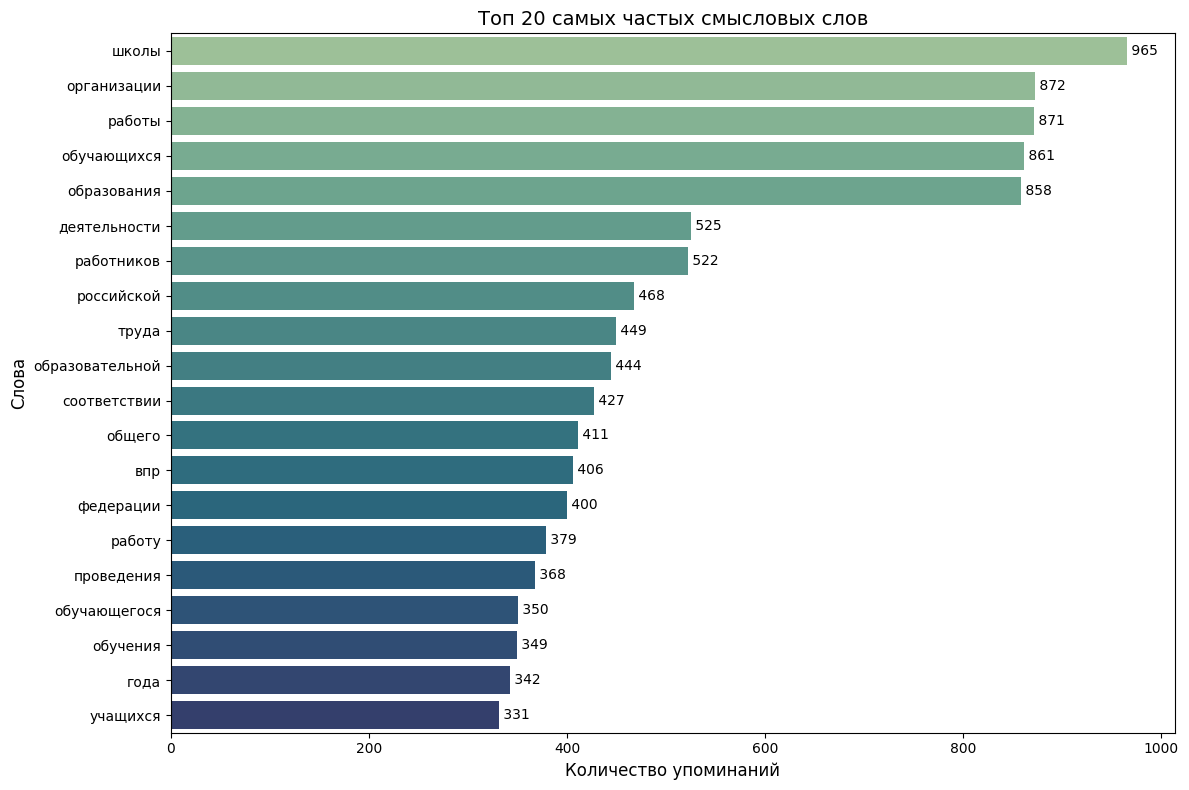

In [18]:
full_text = " ".join(df_cleaned['text'].values).lower()
full_text = full_text.translate(str.maketrans('', '', string.punctuation))

words = full_text.split()
meaningful_words = [
    word for word in words 
    if word not in russian_stopwords and len(word) > 2
]
    
word_counts = Counter(meaningful_words)

top_n = 20
most_common = word_counts.most_common(top_n)
    
# разделяем слова и их количество для графика
words_x, counts_y = zip(*most_common)
    
plt.figure(figsize=(12, 8))
sns.barplot(x=list(counts_y), y=list(words_x), palette="crest")
    
plt.title(f'Топ {top_n} самых частых смысловых слов', fontsize=14)
plt.xlabel('Количество упоминаний', fontsize=12)
plt.ylabel('Слова', fontsize=12)
    
for index, value in enumerate(counts_y):
    plt.text(value, index, f' {value}', va='center', fontsize=10)
        
plt.tight_layout()
plt.show()

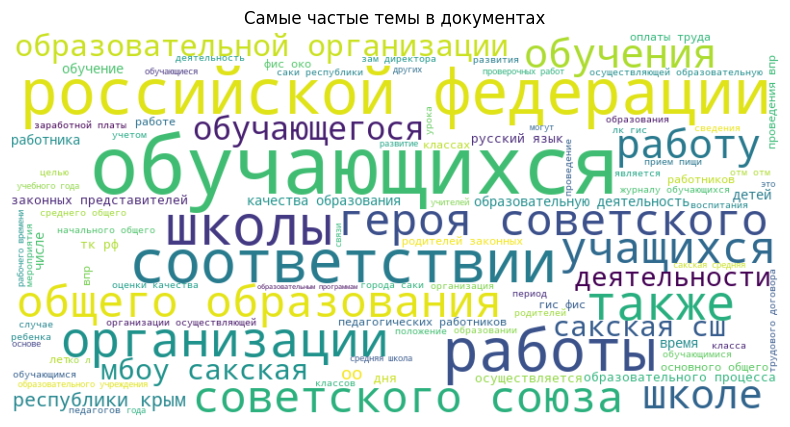

In [19]:
# создаем облако слов
wordcloud = WordCloud(
    width=800, 
    height=400,
    background_color='white',
    stopwords=russian_stopwords,
    colormap='viridis',
    max_words=100
).generate(full_text)
    
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Самые частые темы в документах')
plt.show()

In [20]:
stats = df_cleaned.groupby('format')['size_bytes'].agg(['sum', 'mean', 'max'])
stats['sum_readable'] = stats['sum'].apply(format_size)

In [21]:
print('=== Общая статистика ===')
print(f'Общее кол-во: {len(df_cleaned)}')
print(df_cleaned.groupby('format')['file'].count().rename("Кол-во файлов"))

print("\n=== Анализ веса данных ===")
print(stats)

=== Общая статистика ===
Общее кол-во: 66
format
md     23
pdf    43
Name: Кол-во файлов, dtype: int64

=== Анализ веса данных ===
             sum           mean      max sum_readable
format                                               
md        165153    7180.565217    38458    161.28 KB
pdf     26512093  616560.302326  1812152     25.28 MB
